
# Ứng dụng học máy để phát hiện tấn công web


In [ ]:

# ============================================================
# CELL 1 - Install/check libraries
# ============================================================
import sys, subprocess, importlib.util

REQUIRED_PACKAGES = [
    'pandas', 'numpy', 'sklearn', 'matplotlib', 'joblib', 'tensorflow'
]

def is_installed(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is not None

missing = [p for p in REQUIRED_PACKAGES if not is_installed(p)]
if missing:
    print('Missing packages:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
else:
    print('All required packages are available.')


All required packages are available.


In [ ]:

# ============================================================
# CELL 2 - Mount Google Drive and create project structure
# ============================================================
from google.colab import drive
import os, json, time, hashlib, random, re, html, glob, shutil, subprocess
from pathlib import Path
from datetime import datetime
from urllib.parse import unquote_plus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    drive.mount('/content/drive')
    DRIVE_ROOT = Path('/content/drive/MyDrive')
except Exception as e:
    print('Google Drive mount skipped or failed:', e)
    DRIVE_ROOT = Path('/content')

PROJECT_NAME = 'UngDungHocMay_PhatHienTanCongWeb'
ROOT = DRIVE_ROOT / PROJECT_NAME
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')

DIRS = {
    'root': ROOT,
    'source': ROOT / 'Source',
    'notebooks': ROOT / 'Source' / 'Colab_Notebooks',
    'code': ROOT / 'Source' / 'Code',
    'dataset': ROOT / 'Dataset',
    'raw': ROOT / 'Dataset' / 'Raw',
    'raw_csic': ROOT / 'Dataset' / 'Raw' / 'CSIC2010',
    'raw_sqli': ROOT / 'Dataset' / 'Raw' / 'SQLi',
    'raw_xss': ROOT / 'Dataset' / 'Raw' / 'XSS',
    'raw_httpparams': ROOT / 'Dataset' / 'Raw' / 'HttpParamsDataset',
    'processed': ROOT / 'Dataset' / 'Processed',
    'processed_text': ROOT / 'Dataset' / 'Processed' / 'TextBased',
    'output': ROOT / 'Output',
    'runs': ROOT / 'Output' / 'Runs',
    'tracking': ROOT / 'Output' / 'Tracking',
    'models': ROOT / 'Output' / 'Models',
    'reports': ROOT / 'Output' / 'Reports',
    'figures': ROOT / 'Output' / 'Figures',
    'logs': ROOT / 'Output' / 'Logs',
    'checkpoints': ROOT / 'Output' / 'Checkpoints',
    'application': ROOT / 'Application',
    'app_artifacts': ROOT / 'Application' / 'artifacts',
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

RUN_DIR = DIRS['runs'] / RUN_ID
RUN_SUBDIRS = {
    'data': RUN_DIR / 'data',
    'metrics': RUN_DIR / 'metrics',
    'models': RUN_DIR / 'models',
    'figures': RUN_DIR / 'figures',
    'logs': RUN_DIR / 'logs',
    'artifacts': RUN_DIR / 'artifacts',
}
for p in RUN_SUBDIRS.values():
    p.mkdir(parents=True, exist_ok=True)

print('Project root:', ROOT)
print('Current run:', RUN_DIR)


Mounted at /content/drive
Project root: /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb
Current run: /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb/Output/Runs/20260615_160314


In [ ]:

# ============================================================
# CELL 3 - Global config and safe tracking helpers
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# TASK_MODE:
# - 'binary': Normal vs Attack, phù hợp nhất để bảo vệ chắc chắn.
# - 'multiclass': Normal / SQLi / XSS / CommandInjection / PathTraversal / OtherWebAttack.
TASK_MODE = 'binary'

# Giới hạn số dòng nếu Colab yếu. Đặt None để dùng toàn bộ dữ liệu.
MAX_TEXT_ROWS = None
RUN_DEEP_MODEL = True
RUN_MULTIVIEW_DEEP_MODEL = True
RUN_CROSS_DATASET_EVAL = True

REGISTRY_PATH = DIRS['tracking'] / 'run_registry.csv'
STEP_LOG_PATH = RUN_SUBDIRS['logs'] / 'step_log.jsonl'


def now_iso():
    return datetime.now().isoformat(timespec='seconds')


def log_step(step_name, status='OK', message='', extra=None):
    row = {
        'time': now_iso(),
        'run_id': RUN_ID,
        'step': step_name,
        'status': status,
        'message': message,
        'extra': extra or {},
    }
    with open(STEP_LOG_PATH, 'a', encoding='utf-8') as f:
        f.write(json.dumps(row, ensure_ascii=False) + '\n')
    print(f"[{row['time']}] {step_name} - {status}: {message}")


def safe_save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def safe_save_csv(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding='utf-8')

run_meta = {
    'run_id': RUN_ID,
    'created_at': now_iso(),
    'task_mode': TASK_MODE,
    'seed': SEED,
    'project_root': str(ROOT),
    'dataset_raw_expected': {
        'CSIC2010': str(DIRS['raw_csic']),
        'SQLi': str(DIRS['raw_sqli']),
        'XSS': str(DIRS['raw_xss']),
        'HttpParamsDataset': str(DIRS['raw_httpparams']),
    },
    'note': 'source_dataset is only used for audit/cross-dataset split, not as model feature.'
}
safe_save_json(run_meta, RUN_DIR / 'run_meta.json')
log_step('init_run', 'OK', 'Run metadata saved.', run_meta)


[2026-06-15T16:03:17] init_run - OK: Run metadata saved.



## Cách sắp xếp dataset trên Drive


```text
UngDungHocMay_PhatHienTanCongWeb/
├── Dataset/
│   ├── Raw/
│   │   ├── CSIC2010/
│   │   ├── SQLi/
│   │   ├── XSS/
│   │   └── HttpParamsDataset/
│   └── Processed/TextBased/
├── Output/Runs/<run_id>/
└── Application/artifacts/
```



In [ ]:

# ============================================================
# CELL 4 - Download HttpParamsDataset from GitHub
# ============================================================
http_params_dir = DIRS['raw_httpparams']
http_params_dir.mkdir(parents=True, exist_ok=True)
expected_file = http_params_dir / 'payload_full.csv'

if expected_file.exists():
    print('HttpParamsDataset already exists:', expected_file)
else:
    tmp_repo = Path('/tmp/HttpParamsDataset')
    if tmp_repo.exists():
        shutil.rmtree(tmp_repo)

    subprocess.run(
        ['git', 'clone', '--depth', '1', 'https://github.com/Morzeux/HttpParamsDataset.git', str(tmp_repo)],
        check=True
    )

    for file_name in ['payload_full.csv', 'payload_train.csv', 'payload_test.csv', 'payload_test_lexical.csv', 'LICENSE', 'README.md']:
        src = tmp_repo / file_name
        if src.exists():
            shutil.copy2(src, http_params_dir / file_name)

    print('Downloaded HttpParamsDataset to:', http_params_dir)

log_step('download_httpparams_dataset', 'OK', str(expected_file))


Downloaded HttpParamsDataset to: /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb/Dataset/Raw/HttpParamsDataset
[2026-06-15T16:03:19] download_httpparams_dataset - OK: /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb/Dataset/Raw/HttpParamsDataset/payload_full.csv


In [ ]:

# ============================================================
# CELL 5 - Inspect raw files
# ============================================================
def list_files(folder, patterns=('*.csv', '*.txt', '*.tsv')):
    folder = Path(folder)
    files = []
    for p in patterns:
        files += list(folder.rglob(p))
    return sorted(files)

raw_overview = {}
for key in ['raw_csic', 'raw_sqli', 'raw_xss', 'raw_httpparams']:
    files = list_files(DIRS[key])
    raw_overview[key] = [str(f) for f in files]
    print('\n', key, '=>', DIRS[key])
    if not files:
        print('  No files found yet.')
    for f in files[:20]:
        print(' ', f.name)

safe_save_json(raw_overview, RUN_DIR / 'raw_file_overview.json')
log_step('inspect_raw_files', 'OK', f'Raw overview saved to {RUN_DIR / "raw_file_overview.json"}')



 raw_csic => /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb/Dataset/Raw/CSIC2010
  csic_database.csv

 raw_sqli => /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb/Dataset/Raw/SQLi
  Modified_SQL_Dataset.csv

 raw_xss => /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb/Dataset/Raw/XSS
  XSS_dataset.csv

 raw_httpparams => /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb/Dataset/Raw/HttpParamsDataset
  payload_full.csv
  payload_test.csv
  payload_test_lexical.csv
  payload_train.csv
[2026-06-15T16:03:19] inspect_raw_files - OK: Raw overview saved to /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb/Output/Runs/20260615_160314/raw_file_overview.json


In [ ]:

# ============================================================
# CELL 6 - Dataset column config and normalization helpers
# ============================================================
TEXT_COLUMN_CANDIDATES = [
    'text', 'payload', 'sentence', 'query', 'request', 'url', 'content', 'data',
    'input', 'value', 'raw_text', 'Sentence', 'Payload', 'Query', 'Request', 'URL'
]
LABEL_COLUMN_CANDIDATES = [
    'label', 'Label', 'class', 'Class', 'target', 'Target', 'type', 'Type',
    'attack', 'Attack', 'is_attack', 'malicious', 'result', 'Result', 'attack_type'
]

HTTP_METHOD_RE = re.compile(r'^(GET|POST|PUT|DELETE|PATCH|HEAD|OPTIONS)\s+', re.IGNORECASE)
CONTROL_RE = re.compile(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]')
MULTISPACE_RE = re.compile(r'\s+')

SQL_KEYWORDS = [
    'select', 'union', 'where', 'insert', 'update', 'delete', 'drop',
    'from', 'or', 'and', 'sleep', 'benchmark', 'information_schema'
]
SCRIPT_KEYWORDS = [
    'script', 'javascript', 'alert', 'onerror', 'onload', 'iframe', 'img', 'svg'
]
COMMAND_KEYWORDS = ['cmd', 'exec', 'system', 'powershell', 'bash', 'sh', 'wget', 'curl']
TRAVERSAL_PATTERNS = ['../', '..\\', '%2e', '%2f', '%5c']


def sha256_text(s) -> str:
    if s is None:
        s = ''
    return hashlib.sha256(str(s).encode('utf-8', errors='ignore')).hexdigest()


def is_invalid_text(value) -> bool:
    if value is None or pd.isna(value):
        return True
    s = str(value).strip().lower()
    return s in {'', 'nan', 'none', 'null'}


def safe_decode_text(s, max_rounds: int = 2) -> str:
    if is_invalid_text(s):
        return ''
    s = str(s)
    s = html.unescape(s)
    for _ in range(max_rounds):
        new_s = unquote_plus(s)
        if new_s == s:
            break
        s = new_s
    return s


def normalize_text(s) -> str:
    s = safe_decode_text(s)
    s = CONTROL_RE.sub(' ', s)
    s = s.replace('\r', ' ').replace('\n', ' ').replace('\t', ' ')
    s = MULTISPACE_RE.sub(' ', s).strip()
    return s.lower()


def normalize_label(value, default_attack_label='Attack'):
    if value is None or pd.isna(value):
        return 1, default_attack_label

    v = str(value).strip().lower()
    benign_values = {
        '0', 'normal', 'benign', 'safe', 'clean', 'legitimate',
        'false', 'non-malicious', 'norm'
    }

    if v in benign_values or 'normal' in v or 'benign' in v:
        return 0, 'Normal'

    if 'xss' in v or 'cross-site' in v or 'cross site' in v:
        return 1, 'XSS'

    if 'cmdi' in v or 'command injection' in v or 'os command' in v:
        return 1, 'CommandInjection'

    if 'path-traversal' in v or 'path traversal' in v or 'traversal' in v or 'lfi' in v:
        return 1, 'PathTraversal'

    if 'sqli' in v or 'sql injection' in v or v == 'sql':
        return 1, 'SQLi'

    if v in {'1', 'attack', 'malicious', 'anomalous', 'anomaly', 'anom', 'true'}:
        return 1, default_attack_label

    return 1, default_attack_label


def infer_text_label_columns(df: pd.DataFrame):
    text_col = next((c for c in TEXT_COLUMN_CANDIDATES if c in df.columns), None)
    label_col = next((c for c in LABEL_COLUMN_CANDIDATES if c in df.columns), None)
    if text_col is None:
        # Fallback: choose object column with longest average string length.
        object_cols = [c for c in df.columns if df[c].dtype == 'object']
        if object_cols:
            text_col = max(object_cols, key=lambda c: df[c].astype(str).str.len().mean())
    return text_col, label_col


def extract_http_features(s):
    raw = '' if is_invalid_text(s) else str(s)
    normalized = normalize_text(raw)
    decoded_once = safe_decode_text(raw, max_rounds=1)

    length = max(len(normalized), 1)
    encoded_markers = raw.count('%') + raw.lower().count('&#')
    special_chars = sum(1 for ch in normalized if not ch.isalnum() and not ch.isspace())
    digits = sum(1 for ch in normalized if ch.isdigit())
    letters = sum(1 for ch in normalized if ch.isalpha())

    return {
        'text_length': len(normalized),
        'raw_length': len(raw),
        'decoded_length_delta': abs(len(raw) - len(decoded_once)),
        'num_question_mark': normalized.count('?'),
        'num_ampersand': normalized.count('&'),
        'num_equal': normalized.count('='),
        'num_quote': normalized.count("'") + normalized.count('"'),
        'num_semicolon': normalized.count(';'),
        'num_dash': normalized.count('-'),
        'num_angle_bracket': normalized.count('<') + normalized.count('>'),
        'num_parenthesis': normalized.count('(') + normalized.count(')'),
        'num_slash': normalized.count('/') + normalized.count('\\'),
        'num_percent': raw.count('%'),
        'num_special_chars': special_chars,
        'special_char_ratio': special_chars / length,
        'digit_ratio': digits / length,
        'letter_ratio': letters / length,
        'encoding_marker_count': encoded_markers,
        'encoding_marker_ratio': encoded_markers / max(len(raw), 1),
        'has_http_method': float(bool(HTTP_METHOD_RE.match(normalized))),
        'num_sql_keywords': sum(normalized.count(k) for k in SQL_KEYWORDS),
        'num_script_keywords': sum(normalized.count(k) for k in SCRIPT_KEYWORDS),
        'num_command_keywords': sum(normalized.count(k) for k in COMMAND_KEYWORDS),
        'num_traversal_patterns': sum(normalized.count(k) for k in TRAVERSAL_PATTERNS),
    }

NUMERIC_FEATURE_COLS = list(extract_http_features('sample').keys())
print('Numeric feature columns:', NUMERIC_FEATURE_COLS)
log_step('define_helpers', 'OK', 'Normalization and feature helpers ready.')


Numeric feature columns: ['text_length', 'raw_length', 'decoded_length_delta', 'num_question_mark', 'num_ampersand', 'num_equal', 'num_quote', 'num_semicolon', 'num_dash', 'num_angle_bracket', 'num_parenthesis', 'num_slash', 'num_percent', 'num_special_chars', 'special_char_ratio', 'digit_ratio', 'letter_ratio', 'encoding_marker_count', 'encoding_marker_ratio', 'has_http_method', 'num_sql_keywords', 'num_script_keywords', 'num_command_keywords', 'num_traversal_patterns']
[2026-06-15T16:03:19] define_helpers - OK: Normalization and feature helpers ready.


In [ ]:

# ============================================================
# CELL 7 - Load CSIC 2010 / CSIC-like files
# ============================================================
def split_http_blocks(text: str):
    if not text:
        return []
    normalized = text.replace('\r\n', '\n').replace('\r', '\n')

    # Split by request start when raw file contains multiple HTTP requests.
    starts = [m.start() for m in re.finditer(r'(?m)^(GET|POST|PUT|DELETE|PATCH|HEAD|OPTIONS)\s+', normalized, flags=re.IGNORECASE)]
    if len(starts) > 1:
        blocks = []
        for i, st in enumerate(starts):
            end = starts[i + 1] if i + 1 < len(starts) else len(normalized)
            block = normalized[st:end].strip()
            if block:
                blocks.append(block)
        return blocks

    # Split by blank lines.
    blocks = [b.strip() for b in re.split(r'\n\s*\n', normalized) if b.strip()]
    if len(blocks) > 1:
        return blocks

    # Fallback line-by-line.
    return [line.strip() for line in normalized.splitlines() if line.strip()]


def infer_csic_label_from_path(fp: Path):
    path_text = str(fp).lower()
    if any(k in path_text for k in ['normal', 'valid', 'benign']):
        return 0, 'Normal'
    if any(k in path_text for k in ['attack', 'anomal', 'sqli', 'xss', 'malicious']):
        return 1, 'OtherWebAttack'
    return None, None


def load_csic_dataset(folder: Path) -> pd.DataFrame:
    records = []
    files = list_files(folder)
    for fp in files:
        label_binary_hint, label_multi_hint = infer_csic_label_from_path(fp)
        try:
            if fp.suffix.lower() in ['.csv', '.tsv']:
                sep = '\t' if fp.suffix.lower() == '.tsv' else ','
                try:
                    df = pd.read_csv(fp, sep=sep, low_memory=False)
                except UnicodeDecodeError:
                    df = pd.read_csv(fp, sep=sep, encoding='latin1', low_memory=False)
                text_col, label_col = infer_text_label_columns(df)
                if text_col is None:
                    continue
                for _, row in df.iterrows():
                    raw_text = row[text_col]
                    if is_invalid_text(raw_text):
                        continue
                    if label_col is not None:
                        lb, lm = normalize_label(row[label_col], default_attack_label='OtherWebAttack')
                    else:
                        lb, lm = label_binary_hint, label_multi_hint
                    if lb is None:
                        continue
                    records.append({
                        'source_dataset': 'CSIC2010',
                        'text_type': 'http_request',
                        'raw_text': str(raw_text),
                        'label_binary': lb,
                        'label_multiclass': lm,
                        'source_file': fp.name,
                    })
            else:
                text = fp.read_text(encoding='latin1', errors='ignore')
                for block in split_http_blocks(text):
                    if is_invalid_text(block):
                        continue
                    lb, lm = label_binary_hint, label_multi_hint
                    if lb is None:
                        continue
                    records.append({
                        'source_dataset': 'CSIC2010',
                        'text_type': 'http_request',
                        'raw_text': str(block),
                        'label_binary': lb,
                        'label_multiclass': lm,
                        'source_file': fp.name,
                    })
        except Exception as e:
            print('Skip CSIC file:', fp, e)

    return pd.DataFrame(records)

csic_df = load_csic_dataset(DIRS['raw_csic'])
print('CSIC rows:', len(csic_df))
if not csic_df.empty:
    display(csic_df.head(3))
    print(csic_df['label_multiclass'].value_counts(dropna=False))
log_step('load_csic_dataset', 'OK', f'Loaded CSIC rows: {len(csic_df)}')


CSIC rows: 0
[2026-06-15T16:03:24] load_csic_dataset - OK: Loaded CSIC rows: 0


In [ ]:

# ============================================================
# CELL 8 - Load SQLi and XSS payload datasets
# ============================================================
def load_payload_dataset(folder: Path, source_name: str, default_attack_label: str) -> pd.DataFrame:
    records = []
    files = list_files(folder, patterns=('*.csv', '*.tsv', '*.txt'))
    for fp in files:
        try:
            if fp.suffix.lower() == '.tsv':
                df = pd.read_csv(fp, sep='\t', low_memory=False)
            elif fp.suffix.lower() == '.csv':
                try:
                    df = pd.read_csv(fp, low_memory=False)
                except UnicodeDecodeError:
                    df = pd.read_csv(fp, encoding='latin1', low_memory=False)
            else:
                lines = [x.strip() for x in fp.read_text(encoding='latin1', errors='ignore').splitlines() if x.strip()]
                df = pd.DataFrame({'text': lines, 'label': default_attack_label})
        except Exception as e:
            print('Skip unreadable file:', fp, e)
            continue

        text_col, label_col = infer_text_label_columns(df)
        if text_col is None:
            print('Skip file because no text column found:', fp, list(df.columns))
            continue

        for _, row in df.iterrows():
            raw_text = row[text_col]
            if is_invalid_text(raw_text):
                continue
            if label_col is not None:
                lb, lm = normalize_label(row[label_col], default_attack_label=default_attack_label)
            else:
                lb, lm = 1, default_attack_label
            records.append({
                'source_dataset': source_name,
                'text_type': 'payload_or_query',
                'raw_text': str(raw_text),
                'label_binary': lb,
                'label_multiclass': lm,
                'source_file': fp.name,
            })

    return pd.DataFrame(records)

sqli_df = load_payload_dataset(DIRS['raw_sqli'], 'SQLI_DATASET', 'SQLi')
xss_df = load_payload_dataset(DIRS['raw_xss'], 'XSS_DATASET', 'XSS')

print('SQLi rows:', len(sqli_df))
if not sqli_df.empty:
    print(sqli_df['label_multiclass'].value_counts(dropna=False))
print('XSS rows:', len(xss_df))
if not xss_df.empty:
    print(xss_df['label_multiclass'].value_counts(dropna=False))
log_step('load_payload_datasets', 'OK', f'SQLi={len(sqli_df)}, XSS={len(xss_df)}')


SQLi rows: 30918
label_multiclass
Normal    19537
SQLi      11381
Name: count, dtype: int64
XSS rows: 13570
label_multiclass
XSS       7373
Normal    6197
Name: count, dtype: int64
[2026-06-15T16:03:29] load_payload_datasets - OK: SQLi=30918, XSS=13570


In [ ]:

# ============================================================
# CELL 9 - Load HttpParamsDataset
# ============================================================
def load_httpparams_dataset(folder: Path) -> pd.DataFrame:
    records = []
    fp = folder / 'payload_full.csv'
    if not fp.exists():
        print('Missing HttpParamsDataset file:', fp)
        return pd.DataFrame(records)

    try:
        df = pd.read_csv(fp, low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(fp, encoding='latin1', low_memory=False)

    required_cols = {'payload', 'attack_type', 'label'}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f'HttpParamsDataset missing columns: {missing_cols}. Available columns: {list(df.columns)}')

    for _, row in df.iterrows():
        raw_text = row['payload']
        if is_invalid_text(raw_text):
            continue

        label_val = row['label']
        attack_type = row['attack_type']

        if str(label_val).strip().lower() == 'norm':
            lb, lm = 0, 'Normal'
        else:
            lb, lm = normalize_label(attack_type, default_attack_label='OtherWebAttack')

        records.append({
            'source_dataset': 'HTTPPARAMS_DATASET',
            'text_type': 'http_parameter_value',
            'raw_text': str(raw_text),
            'label_binary': lb,
            'label_multiclass': lm,
            'source_file': fp.name,
        })

    return pd.DataFrame(records)

httpparams_df = load_httpparams_dataset(DIRS['raw_httpparams'])
print('HttpParamsDataset rows:', len(httpparams_df))
if not httpparams_df.empty:
    display(httpparams_df.head(3))
    print(httpparams_df['label_multiclass'].value_counts(dropna=False))
log_step('load_httpparams_dataset', 'OK', f'Loaded HttpParamsDataset rows: {len(httpparams_df)}')


HttpParamsDataset rows: 31067


,source_dataset,text_type,raw_text,label_binary,label_multiclass,source_file
0,HTTPPARAMS_DATASET,http_parameter_value,c/ caridad s/n,0,Normal,payload_full.csv
1,HTTPPARAMS_DATASET,http_parameter_value,"campello, el",0,Normal,payload_full.csv
2,HTTPPARAMS_DATASET,http_parameter_value,40184,0,Normal,payload_full.csv


label_multiclass
Normal              19304
SQLi                10852
XSS                   532
PathTraversal         290
CommandInjection       89
Name: count, dtype: int64
[2026-06-15T16:03:30] load_httpparams_dataset - OK: Loaded HttpParamsDataset rows: 31067


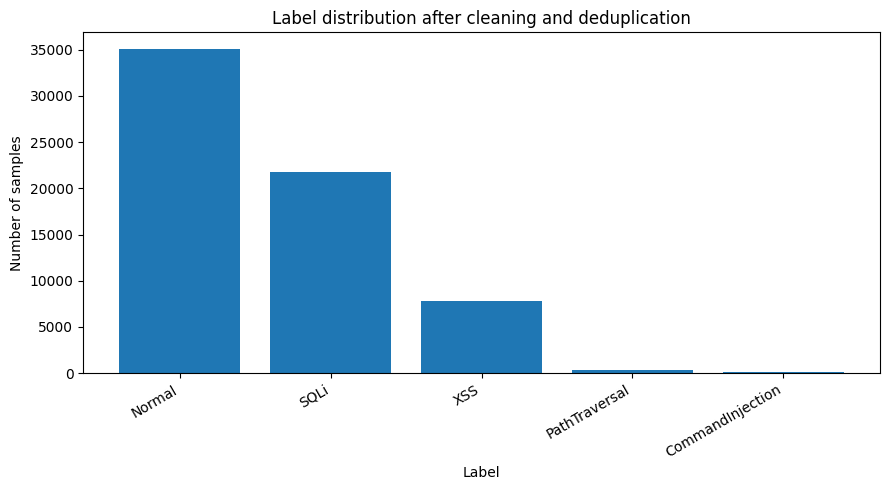

Cleaning audit:
{
  "rows_before_invalid_removal": 75555,
  "rows_after_invalid_raw_removal": 75555,
  "label_conflict_groups": 3,
  "rows_before_conflict_removal": 75555,
  "rows_after_conflict_removal": 75542,
  "rows_removed_by_conflict": 13,
  "rows_before_dedup": 75542,
  "rows_after_dedup": 65109,
  "rows_removed_by_dedup": 10433,
  "final_rows": 65109
}

Dataset summary:


,source_dataset,rows,normal_rows,attack_rows,multiclass_labels
0,HTTPPARAMS_DATASET,23469,12098,11371,"CommandInjection, Normal, PathTraversal, SQLi,..."
1,SQLI_DATASET,30799,19504,11295,"Normal, SQLi"
2,XSS_DATASET,10841,3531,7310,"Normal, XSS"



Label distribution:


,label,count
0,Normal,35133
1,SQLi,21759
2,XSS,7838
3,PathTraversal,290
4,CommandInjection,89


[2026-06-15T16:03:44] build_standardized_dataset - OK: Standardized dataset, conflict audit, dedup and label distribution saved.


In [ ]:

# ============================================================
# CELL 10 - Build standardized text-based dataset
# Includes label conflict audit and dedup before split.
# ============================================================
frames = [df for df in [csic_df, sqli_df, xss_df, httpparams_df] if df is not None and not df.empty]
text_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

if text_df.empty:
    raise RuntimeError(
        'No text-based data found. Please upload datasets to Raw folders or run HttpParamsDataset download.'
    )

# Remove invalid raw texts before normalization.
before_invalid = len(text_df)
text_df = text_df[~text_df['raw_text'].apply(is_invalid_text)].copy()
after_invalid = len(text_df)

text_df['normalized_text'] = text_df['raw_text'].apply(normalize_text)
text_df = text_df[~text_df['normalized_text'].apply(is_invalid_text)].copy()
text_df['raw_hash'] = text_df['raw_text'].apply(sha256_text)
text_df['normalized_hash'] = text_df['normalized_text'].apply(sha256_text)

# Label conflict audit before duplicate removal.
conflict_df = (
    text_df
    .groupby('normalized_hash')
    .agg(
        sample_count=('normalized_hash', 'size'),
        label_count=('label_multiclass', 'nunique'),
        labels=('label_multiclass', lambda x: sorted(set(x))),
        binary_labels=('label_binary', lambda x: sorted(set(x))),
        sources=('source_dataset', lambda x: sorted(set(x))),
        example_text=('normalized_text', 'first')
    )
    .reset_index()
)
label_conflicts = conflict_df[conflict_df['label_count'] > 1].copy()
safe_save_csv(label_conflicts, RUN_SUBDIRS['data'] / 'label_conflicts_before_dedup.csv')

# Remove conflicting texts to avoid noisy labels.
conflict_hashes = set(label_conflicts['normalized_hash'])
before_conflict_removal = len(text_df)
text_df = text_df[~text_df['normalized_hash'].isin(conflict_hashes)].reset_index(drop=True)
after_conflict_removal = len(text_df)

# Deduplicate BEFORE train/validation/test split to reduce leakage.
before_dedup = len(text_df)
text_df = text_df.drop_duplicates(subset=['normalized_hash'], keep='first').reset_index(drop=True)
after_dedup = len(text_df)

if MAX_TEXT_ROWS is not None and len(text_df) > MAX_TEXT_ROWS:
    text_df, _ = train_test_split(
        text_df,
        train_size=MAX_TEXT_ROWS,
        stratify=text_df['label_binary'] if text_df['label_binary'].nunique() > 1 else None,
        random_state=SEED,
    )
    text_df = text_df.reset_index(drop=True)

# Add transparent numerical features.
feature_df = pd.DataFrame(text_df['raw_text'].apply(extract_http_features).tolist())
text_df = pd.concat([text_df.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)

# Choose label column.
LABEL_COL = 'label_binary' if TASK_MODE == 'binary' else 'label_multiclass'
text_col = 'normalized_text'

# Dataset summaries.
dataset_summary = (
    text_df.groupby('source_dataset')
    .agg(
        rows=('source_dataset', 'size'),
        normal_rows=('label_binary', lambda x: int((x == 0).sum())),
        attack_rows=('label_binary', lambda x: int((x == 1).sum())),
        multiclass_labels=('label_multiclass', lambda x: ', '.join(sorted(set(map(str, x)))))
    )
    .reset_index()
)
label_distribution = text_df['label_multiclass'].value_counts().rename_axis('label').reset_index(name='count')

safe_save_csv(text_df, RUN_SUBDIRS['data'] / 'standardized_text_dataset.csv')
safe_save_csv(text_df, DIRS['processed_text'] / f'standardized_text_dataset_{RUN_ID}.csv')
safe_save_csv(dataset_summary, RUN_SUBDIRS['data'] / 'dataset_summary.csv')
safe_save_csv(label_distribution, RUN_SUBDIRS['data'] / 'label_distribution.csv')

# Figure 1: label distribution.
plt.figure(figsize=(9, 5))
plt.bar(label_distribution['label'].astype(str), label_distribution['count'])
plt.title('Label distribution after cleaning and deduplication')
plt.xlabel('Label')
plt.ylabel('Number of samples')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(RUN_SUBDIRS['figures'] / 'label_distribution.png', dpi=160)
plt.show()

cleaning_audit = {
    'rows_before_invalid_removal': int(before_invalid),
    'rows_after_invalid_raw_removal': int(after_invalid),
    'label_conflict_groups': int(len(label_conflicts)),
    'rows_before_conflict_removal': int(before_conflict_removal),
    'rows_after_conflict_removal': int(after_conflict_removal),
    'rows_removed_by_conflict': int(before_conflict_removal - after_conflict_removal),
    'rows_before_dedup': int(before_dedup),
    'rows_after_dedup': int(after_dedup),
    'rows_removed_by_dedup': int(before_dedup - after_dedup),
    'final_rows': int(len(text_df)),
}
safe_save_json(cleaning_audit, RUN_SUBDIRS['metrics'] / 'cleaning_audit.json')

print('Cleaning audit:')
print(json.dumps(cleaning_audit, indent=2, ensure_ascii=False))
print('\nDataset summary:')
display(dataset_summary)
print('\nLabel distribution:')
display(label_distribution)
log_step('build_standardized_dataset', 'OK', 'Standardized dataset, conflict audit, dedup and label distribution saved.', cleaning_audit)


In [ ]:

# ============================================================
# CELL 11 - Train/validation/test split and leakage audit
# ============================================================
if text_df[LABEL_COL].nunique() < 2:
    raise RuntimeError(f'Need at least 2 classes in {LABEL_COL}. Current classes: {text_df[LABEL_COL].unique()}')

train_df, temp_df = train_test_split(
    text_df,
    test_size=0.30,
    stratify=text_df[LABEL_COL],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df[LABEL_COL],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

safe_save_csv(train_df, RUN_SUBDIRS['data'] / 'train_text.csv')
safe_save_csv(val_df, RUN_SUBDIRS['data'] / 'validation_text.csv')
safe_save_csv(test_df, RUN_SUBDIRS['data'] / 'test_text.csv')

# Hash overlap audit.
train_hashes = set(train_df['normalized_hash'])
val_hashes = set(val_df['normalized_hash'])
test_hashes = set(test_df['normalized_hash'])
leakage_audit = {
    'train_rows': int(len(train_df)),
    'validation_rows': int(len(val_df)),
    'test_rows': int(len(test_df)),
    'train_validation_hash_overlap': int(len(train_hashes & val_hashes)),
    'train_test_hash_overlap': int(len(train_hashes & test_hashes)),
    'validation_test_hash_overlap': int(len(val_hashes & test_hashes)),
    'duplicate_removed_before_split': True,
    'label_conflict_checked': True,
    'tfidf_fit_scope': 'train_only',
    'scaler_fit_scope': 'train_only',
    'tokenizer_fit_scope': 'train_only',
    'source_dataset_used_as_feature': False,
}
safe_save_json(leakage_audit, RUN_SUBDIRS['metrics'] / 'leakage_audit.json')

split_report = {
    'task_mode': TASK_MODE,
    'label_col': LABEL_COL,
    'train_label_distribution': train_df[LABEL_COL].value_counts().to_dict(),
    'validation_label_distribution': val_df[LABEL_COL].value_counts().to_dict(),
    'test_label_distribution': test_df[LABEL_COL].value_counts().to_dict(),
}
safe_save_json(split_report, RUN_SUBDIRS['metrics'] / 'text_split_report.json')

print('Leakage audit:')
print(json.dumps(leakage_audit, indent=2, ensure_ascii=False))
print('\nSplit report:')
print(json.dumps(split_report, indent=2, ensure_ascii=False))

assert leakage_audit['train_validation_hash_overlap'] == 0
assert leakage_audit['train_test_hash_overlap'] == 0
assert leakage_audit['validation_test_hash_overlap'] == 0

log_step('split_and_leakage_audit', 'OK', 'Train/validation/test split completed with zero normalized hash overlap.', leakage_audit)


Leakage audit:
{
  "train_rows": 45576,
  "validation_rows": 9766,
  "test_rows": 9767,
  "train_validation_hash_overlap": 0,
  "train_test_hash_overlap": 0,
  "validation_test_hash_overlap": 0,
  "duplicate_removed_before_split": true,
  "label_conflict_checked": true,
  "tfidf_fit_scope": "train_only",
  "scaler_fit_scope": "train_only",
  "tokenizer_fit_scope": "train_only",
  "source_dataset_used_as_feature": false
}

Split report:
{
  "task_mode": "binary",
  "label_col": "label_binary",
  "train_label_distribution": {
    "0": 24593,
    "1": 20983
  },
  "validation_label_distribution": {
    "0": 5270,
    "1": 4496
  },
  "test_label_distribution": {
    "0": 5270,
    "1": 4497
  }
}
[2026-06-15T16:03:46] split_and_leakage_audit - OK: Train/validation/test split completed with zero normalized hash overlap.


In [ ]:

# ============================================================
# CELL 12 - Evaluation helpers and artifact saving
# ============================================================
model_metrics = []
model_registry = {}


def binary_security_metrics(y_true, y_pred):
    y_true_s = pd.Series(y_true).astype(str)
    y_pred_s = pd.Series(y_pred).astype(str)
    values = sorted(set(y_true_s.unique()).union(set(y_pred_s.unique())))

    if '0' in values and '1' in values:
        neg_label, pos_label = '0', '1'
    elif 'Normal' in values:
        neg_label = 'Normal'
        pos_candidates = [v for v in values if v != 'Normal']
        pos_label = pos_candidates[0] if pos_candidates else values[-1]
    else:
        neg_label, pos_label = values[0], values[-1]

    cm_bin = confusion_matrix(y_true_s, y_pred_s, labels=[neg_label, pos_label])
    if cm_bin.shape != (2, 2):
        return {}
    tn, fp, fn, tp = cm_bin.ravel()
    return {
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
        'attack_precision': float(tp / max(tp + fp, 1)),
        'attack_recall': float(tp / max(tp + fn, 1)),
        'attack_f1': float((2 * tp) / max((2 * tp + fp + fn), 1)),
        'false_positive_rate': float(fp / max(fp + tn, 1)),
        'false_negative_rate': float(fn / max(fn + tp, 1)),
    }


def evaluate_predictions(y_true, y_pred, model_name, labels=None, y_score=None, train_time_sec=None, inference_time_ms=None):
    if labels is None:
        labels = sorted(pd.Series(y_true).astype(str).unique().tolist())

    y_true_eval = pd.Series(y_true).astype(str)
    y_pred_eval = pd.Series(y_pred).astype(str)
    labels_eval = sorted(set(labels) | set(y_true_eval.unique()) | set(y_pred_eval.unique()))

    acc = accuracy_score(y_true_eval, y_pred_eval)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true_eval, y_pred_eval, average='weighted', zero_division=0
    )
    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        y_true_eval, y_pred_eval, average='macro', zero_division=0
    )

    metrics = {
        'model_name': model_name,
        'task_mode': TASK_MODE,
        'accuracy': float(acc),
        'precision_weighted': float(precision_w),
        'recall_weighted': float(recall_w),
        'f1_weighted': float(f1_w),
        'precision_macro': float(precision_m),
        'recall_macro': float(recall_m),
        'f1_macro': float(f1_m),
        'train_time_sec': None if train_time_sec is None else float(train_time_sec),
        'inference_time_ms': None if inference_time_ms is None else float(inference_time_ms),
    }

    if TASK_MODE == 'binary':
        metrics.update(binary_security_metrics(y_true_eval, y_pred_eval))
        if y_score is not None:
            try:
                metrics['roc_auc'] = float(roc_auc_score(y_true_eval.astype(int), y_score))
            except Exception as e:
                metrics['roc_auc_error'] = str(e)

    report_dict = classification_report(y_true_eval, y_pred_eval, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true_eval, y_pred_eval, labels=labels_eval)
    return metrics, report_dict, cm, labels_eval


def plot_confusion_matrix(cm, labels, title, path):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.yticks(range(len(labels)), labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center')
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.show()


def save_eval_artifacts(model_name, metrics, report_dict, cm, labels):
    safe_save_json(metrics, RUN_SUBDIRS['metrics'] / f'{model_name}_metrics.json')
    safe_save_json(report_dict, RUN_SUBDIRS['metrics'] / f'{model_name}_classification_report.json')
    cm_df = pd.DataFrame(cm, index=[f'true_{x}' for x in labels], columns=[f'pred_{x}' for x in labels])
    safe_save_csv(cm_df.reset_index(), RUN_SUBDIRS['metrics'] / f'{model_name}_confusion_matrix.csv')
    plot_confusion_matrix(cm, labels, f'Confusion matrix - {model_name}', RUN_SUBDIRS['figures'] / f'{model_name}_confusion_matrix.png')
    model_metrics.append(metrics)
    print(json.dumps(metrics, indent=2, ensure_ascii=False))

log_step('define_evaluation_helpers', 'OK', 'Evaluation helpers ready.')


[2026-06-15T16:03:46] define_evaluation_helpers - OK: Evaluation helpers ready.


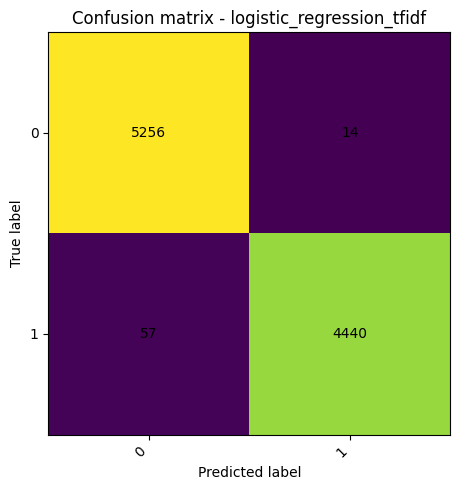

{
  "model_name": "logistic_regression_tfidf",
  "task_mode": "binary",
  "accuracy": 0.9927306235282072,
  "precision_weighted": 0.992764017802819,
  "recall_weighted": 0.9927306235282072,
  "f1_weighted": 0.9927279309060075,
  "precision_macro": 0.993064177968807,
  "recall_macro": 0.9923341683829701,
  "f1_macro": 0.9926795263255331,
  "train_time_sec": 11.85800316399991,
  "inference_time_ms": 0.11932377669704805,
  "tn": 5256,
  "fp": 14,
  "fn": 57,
  "tp": 4440,
  "attack_precision": 0.9968567579703638,
  "attack_recall": 0.9873248832555037,
  "attack_f1": 0.9920679253714669,
  "false_positive_rate": 0.0026565464895635673,
  "false_negative_rate": 0.012675116744496331,
  "roc_auc": 0.9993940299225416
}


In [ ]:

# ============================================================
# CELL 13 - Baseline 1: TF-IDF + Logistic Regression
# ============================================================
model_name = 'logistic_regression_tfidf'

X_train = train_df[text_col].astype(str)
X_test = test_df[text_col].astype(str)
y_train = train_df[LABEL_COL]
y_test = test_df[LABEL_COL]

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_features=100000)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=SEED))
])

start = time.perf_counter()
lr_pipeline.fit(X_train, y_train)
train_time = time.perf_counter() - start

start = time.perf_counter()
y_pred = lr_pipeline.predict(X_test)
inference_ms = (time.perf_counter() - start) / max(len(X_test), 1) * 1000

y_score = None
if TASK_MODE == 'binary':
    try:
        y_score = lr_pipeline.predict_proba(X_test)[:, 1]
    except Exception:
        y_score = None

labels = sorted(pd.Series(y_test).astype(str).unique().tolist())
metrics, report_dict, cm, labels = evaluate_predictions(y_test, y_pred, model_name, labels, y_score, train_time, inference_ms)
save_eval_artifacts(model_name, metrics, report_dict, cm, labels)
model_path = RUN_SUBDIRS['models'] / f'{model_name}.joblib'
joblib.dump(lr_pipeline, model_path)
model_registry[model_name] = {'path': str(model_path), 'input_type': 'text', 'model': lr_pipeline}


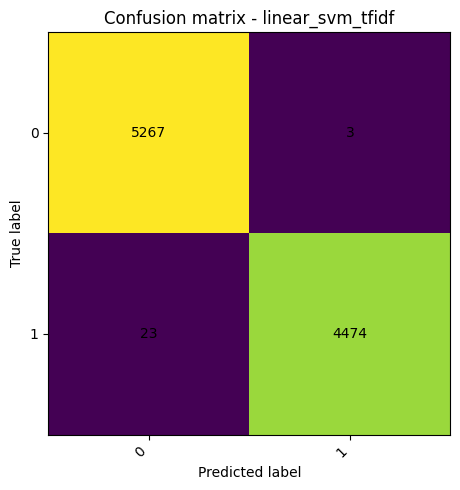

{
  "model_name": "linear_svm_tfidf",
  "task_mode": "binary",
  "accuracy": 0.9973379748131463,
  "precision_weighted": 0.9973455057530619,
  "recall_weighted": 0.9973379748131463,
  "f1_weighted": 0.9973375292950388,
  "precision_macro": 0.9974910411669304,
  "recall_macro": 0.9971581096231559,
  "f1_macro": 0.9973203100201931,
  "train_time_sec": 8.739808642000071,
  "inference_time_ms": 0.12495447107606103,
  "tn": 5267,
  "fp": 3,
  "fn": 23,
  "tp": 4474,
  "attack_precision": 0.9993299084208175,
  "attack_recall": 0.9948854792083611,
  "attack_f1": 0.9971027412525072,
  "false_positive_rate": 0.0005692599620493358,
  "false_negative_rate": 0.005114520791638871,
  "roc_auc": 0.9996291856388341
}


In [ ]:

# ============================================================
# CELL 14 - Baseline 2: TF-IDF + Linear SVM
# ============================================================
model_name = 'linear_svm_tfidf'

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_features=120000)),
    ('clf', LinearSVC(class_weight='balanced', random_state=SEED))
])

start = time.perf_counter()
svm_pipeline.fit(X_train, y_train)
train_time = time.perf_counter() - start

start = time.perf_counter()
y_pred = svm_pipeline.predict(X_test)
inference_ms = (time.perf_counter() - start) / max(len(X_test), 1) * 1000

y_score = None
if TASK_MODE == 'binary':
    try:
        y_score = svm_pipeline.decision_function(X_test)
    except Exception:
        y_score = None

labels = sorted(pd.Series(y_test).astype(str).unique().tolist())
metrics, report_dict, cm, labels = evaluate_predictions(y_test, y_pred, model_name, labels, y_score, train_time, inference_ms)
save_eval_artifacts(model_name, metrics, report_dict, cm, labels)
model_path = RUN_SUBDIRS['models'] / f'{model_name}.joblib'
joblib.dump(svm_pipeline, model_path)
model_registry[model_name] = {'path': str(model_path), 'input_type': 'text', 'model': svm_pipeline}


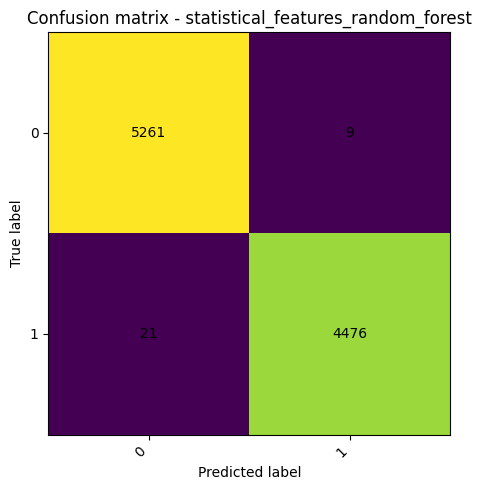

{
  "model_name": "statistical_features_random_forest",
  "task_mode": "binary",
  "accuracy": 0.9969284324767073,
  "precision_weighted": 0.9969308517388659,
  "recall_weighted": 0.9969284324767073,
  "f1_weighted": 0.9969281271933449,
  "precision_macro": 0.9970087721408862,
  "recall_macro": 0.9968112201303083,
  "f1_macro": 0.9969084618567436,
  "train_time_sec": 13.333078980999971,
  "inference_time_ms": 0.04627395617897038,
  "tn": 5261,
  "fp": 9,
  "fn": 21,
  "tp": 4476,
  "attack_precision": 0.9979933110367893,
  "attack_recall": 0.9953302201467645,
  "attack_f1": 0.9966599866399466,
  "false_positive_rate": 0.0017077798861480076,
  "false_negative_rate": 0.004669779853235491,
  "roc_auc": 0.9996971415478756
}


In [ ]:

# ============================================================
# CELL 15 - Baseline 3: HTTP/text statistical features + Random Forest
# ============================================================
model_name = 'statistical_features_random_forest'

X_train_num = train_df[NUMERIC_FEATURE_COLS].fillna(0)
X_test_num = test_df[NUMERIC_FEATURE_COLS].fillna(0)

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced_subsample',
        random_state=SEED,
        n_jobs=-1
    ))
])

start = time.perf_counter()
rf_pipeline.fit(X_train_num, y_train)
train_time = time.perf_counter() - start

start = time.perf_counter()
y_pred = rf_pipeline.predict(X_test_num)
inference_ms = (time.perf_counter() - start) / max(len(X_test_num), 1) * 1000

y_score = None
if TASK_MODE == 'binary':
    try:
        y_score = rf_pipeline.predict_proba(X_test_num)[:, 1]
    except Exception:
        y_score = None

labels = sorted(pd.Series(y_test).astype(str).unique().tolist())
metrics, report_dict, cm, labels = evaluate_predictions(y_test, y_pred, model_name, labels, y_score, train_time, inference_ms)
save_eval_artifacts(model_name, metrics, report_dict, cm, labels)
model_path = RUN_SUBDIRS['models'] / f'{model_name}.joblib'
joblib.dump(rf_pipeline, model_path)
model_registry[model_name] = {'path': str(model_path), 'input_type': 'numeric', 'model': rf_pipeline}


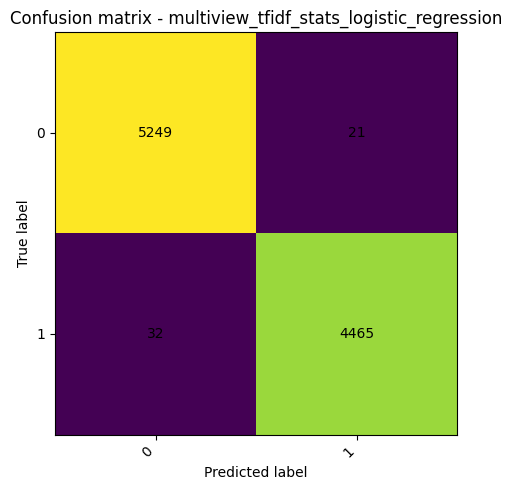

{
  "model_name": "multiview_tfidf_stats_logistic_regression",
  "task_mode": "binary",
  "accuracy": 0.9945735640421829,
  "precision_weighted": 0.9945751162595835,
  "recall_weighted": 0.9945735640421829,
  "f1_weighted": 0.9945730702907069,
  "precision_macro": 0.9946296555346124,
  "recall_macro": 0.9944496626256003,
  "f1_macro": 0.9945383730278846,
  "train_time_sec": 14.01418197299995,
  "inference_time_ms": 0.19635595495034752,
  "tn": 5249,
  "fp": 21,
  "fn": 32,
  "tp": 4465,
  "attack_precision": 0.9953187695051271,
  "attack_recall": 0.9928841449855459,
  "attack_f1": 0.9940999666035846,
  "false_positive_rate": 0.003984819734345351,
  "false_negative_rate": 0.00711585501445408,
  "roc_auc": 0.9981893052041019
}


In [ ]:

# ============================================================
# CELL 16 - Baseline 4: Multi-view classical model
# Text TF-IDF + HTTP statistical features + Logistic Regression
# ============================================================
model_name = 'multiview_tfidf_stats_logistic_regression'

X_train_mv = train_df[[text_col] + NUMERIC_FEATURE_COLS].copy()
X_test_mv = test_df[[text_col] + NUMERIC_FEATURE_COLS].copy()

preprocess = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_features=100000), text_col),
        ('num', StandardScaler(), NUMERIC_FEATURE_COLS),
    ],
    remainder='drop'
)

mv_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=SEED))
])

start = time.perf_counter()
mv_pipeline.fit(X_train_mv, y_train)
train_time = time.perf_counter() - start

start = time.perf_counter()
y_pred = mv_pipeline.predict(X_test_mv)
inference_ms = (time.perf_counter() - start) / max(len(X_test_mv), 1) * 1000

y_score = None
if TASK_MODE == 'binary':
    try:
        y_score = mv_pipeline.predict_proba(X_test_mv)[:, 1]
    except Exception:
        y_score = None

labels = sorted(pd.Series(y_test).astype(str).unique().tolist())
metrics, report_dict, cm, labels = evaluate_predictions(y_test, y_pred, model_name, labels, y_score, train_time, inference_ms)
save_eval_artifacts(model_name, metrics, report_dict, cm, labels)
model_path = RUN_SUBDIRS['models'] / f'{model_name}.joblib'
joblib.dump(mv_pipeline, model_path)
model_registry[model_name] = {'path': str(model_path), 'input_type': 'multiview', 'model': mv_pipeline}


Epoch 1/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 227s 624ms/step - accuracy: 0.9453 - loss: 0.1274 - val_accuracy: 0.7438 - val_loss: 0.3395
Epoch 2/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 234s 656ms/step - accuracy: 0.9893 - loss: 0.0285 - val_accuracy: 0.9726 - val_loss: 0.1230
Epoch 3/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 248s 616ms/step - accuracy: 0.9927 - loss: 0.0179 - val_accuracy: 0.9733 - val_loss: 0.1011
Epoch 4/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 221s 618ms/step - accuracy: 0.9935 - loss: 0.0162 - val_accuracy: 0.9831 - val_loss: 0.0859
Epoch 5/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 220s 616ms/step - accuracy: 0.9935 - loss: 0.0155 - val_accuracy: 0.9716 - val_loss: 0.1327
Epoch 6/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 216s 607ms/step - accuracy: 0.9934 - loss: 0.0170 - val_accuracy: 0.9828 - val_loss: 0.1011
Epoch 7/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 230s 644ms/step - accuracy: 0.9936 - loss: 0.0154 - val_accuracy: 0.9823 - val_loss: 0.1121


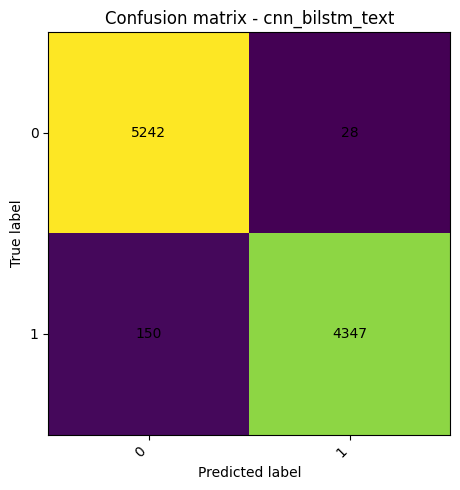

{
  "model_name": "cnn_bilstm_text",
  "task_mode": "binary",
  "accuracy": 0.9817753660284632,
  "precision_weighted": 0.9820429115300449,
  "recall_weighted": 0.9817753660284632,
  "f1_weighted": 0.9817543291416997,
  "precision_macro": 0.9828905044510385,
  "recall_macro": 0.9806656683203097,
  "f1_macro": 0.9816210380476986,
  "train_time_sec": 1596.2997882840002,
  "inference_time_ms": 1.4256947405549012,
  "tn": 5242,
  "fp": 28,
  "fn": 150,
  "tp": 4347,
  "attack_precision": 0.9936,
  "attack_recall": 0.9666444296197465,
  "attack_f1": 0.9799368800721371,
  "false_positive_rate": 0.005313092979127135,
  "false_negative_rate": 0.0333555703802535,
  "roc_auc": 0.9931897250496746
}


In [ ]:

# ============================================================
# CELL 17 - Deep Learning: CNN-BiLSTM text-only model
# ============================================================
if RUN_DEEP_MODEL:
    model_name = 'cnn_bilstm_text'

    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(train_df[LABEL_COL].astype(str))
    y_val_enc = label_encoder.transform(val_df[LABEL_COL].astype(str))
    y_test_enc = label_encoder.transform(test_df[LABEL_COL].astype(str))
    class_names = label_encoder.classes_.tolist()
    num_classes = len(class_names)

    max_tokens = 50000
    sequence_length = 256
    vectorizer = layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode='int',
        output_sequence_length=sequence_length,
        standardize=None,
    )
    # Fit/adapt on TRAIN ONLY to prevent leakage.
    vectorizer.adapt(train_df[text_col].astype(str).values)

    batch_size = 128
    train_ds = tf.data.Dataset.from_tensor_slices((train_df[text_col].astype(str).values, y_train_enc)).shuffle(10000, seed=SEED).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((val_df[text_col].astype(str).values, y_val_enc)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((test_df[text_col].astype(str).values, y_test_enc)).batch(batch_size)

    text_input = keras.Input(shape=(1,), dtype=tf.string, name='text')
    x = vectorizer(text_input)
    x = layers.Embedding(input_dim=max_tokens, output_dim=64, mask_zero=False)(x)
    x = layers.Conv1D(filters=96, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.25)(x)

    if num_classes == 2:
        output = layers.Dense(1, activation='sigmoid', name='output')(x)
        loss = 'binary_crossentropy'
        metrics_list = ['accuracy']
        y_train_model = y_train_enc
        y_val_model = y_val_enc
    else:
        output = layers.Dense(num_classes, activation='softmax', name='output')(x)
        loss = 'sparse_categorical_crossentropy'
        metrics_list = ['accuracy']
        y_train_model = y_train_enc
        y_val_model = y_val_enc

    model = keras.Model(inputs=text_input, outputs=output)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=loss, metrics=metrics_list)

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(RUN_SUBDIRS['models'] / f'{model_name}.keras', monitor='val_loss', save_best_only=True),
    ]

    # Rebuild datasets with correct labels for Keras.
    train_ds = tf.data.Dataset.from_tensor_slices((train_df[text_col].astype(str).values, y_train_model)).shuffle(10000, seed=SEED).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((val_df[text_col].astype(str).values, y_val_model)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    start = time.perf_counter()
    history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks, verbose=1)
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    pred_raw = model.predict(test_df[text_col].astype(str).values, batch_size=batch_size, verbose=0)
    inference_ms = (time.perf_counter() - start) / max(len(test_df), 1) * 1000

    if num_classes == 2:
        y_score = pred_raw.ravel()
        y_pred_enc = (y_score >= 0.5).astype(int)
    else:
        y_score = None
        y_pred_enc = np.argmax(pred_raw, axis=1)

    y_pred = label_encoder.inverse_transform(y_pred_enc)
    y_true = label_encoder.inverse_transform(y_test_enc)
    labels = class_names

    metrics, report_dict, cm, labels = evaluate_predictions(y_true, y_pred, model_name, labels, y_score, train_time, inference_ms)
    save_eval_artifacts(model_name, metrics, report_dict, cm, labels)

    history_df = pd.DataFrame(history.history)
    history_df['epoch'] = np.arange(1, len(history_df) + 1)
    safe_save_csv(history_df, RUN_SUBDIRS['metrics'] / f'{model_name}_history.csv')
    safe_save_json({'classes': class_names}, RUN_SUBDIRS['models'] / f'{model_name}_label_encoder.json')

    # Store registry metadata. Keras export to Streamlit is intentionally not selected by default.
    model_registry[model_name] = {'path': str(RUN_SUBDIRS['models'] / f'{model_name}.keras'), 'input_type': 'keras_text', 'model': None}
else:
    print('RUN_DEEP_MODEL=False, skipped CNN-BiLSTM.')


Epoch 1/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 233s 632ms/step - accuracy: 0.9726 - loss: 0.0719 - val_accuracy: 0.9953 - val_loss: 0.0188
Epoch 2/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 260s 628ms/step - accuracy: 0.9980 - loss: 0.0085 - val_accuracy: 0.9962 - val_loss: 0.0160
Epoch 3/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 225s 629ms/step - accuracy: 0.9992 - loss: 0.0038 - val_accuracy: 0.9964 - val_loss: 0.0263
Epoch 4/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 233s 653ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accuracy: 0.9969 - val_loss: 0.0178
Epoch 5/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 233s 652ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.9962 - val_loss: 0.0171


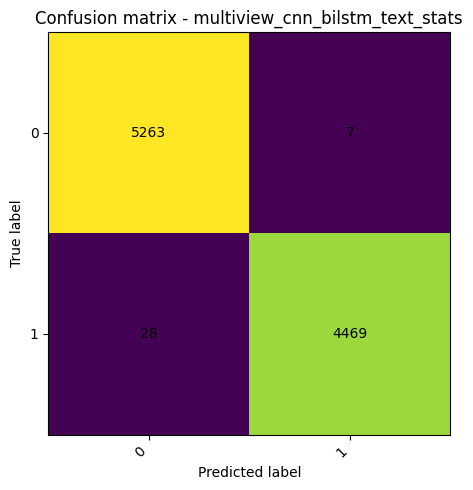

{
  "model_name": "multiview_cnn_bilstm_text_stats",
  "task_mode": "binary",
  "accuracy": 0.9964165045561585,
  "precision_weighted": 0.9964245203530331,
  "recall_weighted": 0.9964165045561585,
  "f1_weighted": 0.9964158740287882,
  "precision_macro": 0.9965720491859902,
  "recall_macro": 0.9962226768087854,
  "f1_macro": 0.996392664616539,
  "train_time_sec": 1182.955786783,
  "inference_time_ms": 2.1045559979522883,
  "tn": 5263,
  "fp": 7,
  "fn": 28,
  "tp": 4469,
  "attack_precision": 0.9984361036639857,
  "attack_recall": 0.9937736268623527,
  "attack_f1": 0.9960994093391285,
  "false_positive_rate": 0.0013282732447817836,
  "false_negative_rate": 0.00622637313764732,
  "roc_auc": 0.9993052294192333
}


In [ ]:

# ============================================================
# CELL 18 - Proposed model: Multi-view CNN-BiLSTM with text + HTTP stats
# ============================================================
if RUN_MULTIVIEW_DEEP_MODEL:
    model_name = 'multiview_cnn_bilstm_text_stats'

    label_encoder_mv = LabelEncoder()
    y_train_enc = label_encoder_mv.fit_transform(train_df[LABEL_COL].astype(str))
    y_val_enc = label_encoder_mv.transform(val_df[LABEL_COL].astype(str))
    y_test_enc = label_encoder_mv.transform(test_df[LABEL_COL].astype(str))
    class_names = label_encoder_mv.classes_.tolist()
    num_classes = len(class_names)

    # Fit scaler on TRAIN ONLY.
    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(train_df[NUMERIC_FEATURE_COLS].fillna(0))
    X_val_num = scaler.transform(val_df[NUMERIC_FEATURE_COLS].fillna(0))
    X_test_num = scaler.transform(test_df[NUMERIC_FEATURE_COLS].fillna(0))

    max_tokens = 50000
    sequence_length = 256
    vectorizer_mv = layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode='int',
        output_sequence_length=sequence_length,
        standardize=None,
    )
    # Fit/adapt on TRAIN ONLY.
    vectorizer_mv.adapt(train_df[text_col].astype(str).values)

    text_input = keras.Input(shape=(1,), dtype=tf.string, name='text')
    text_branch = vectorizer_mv(text_input)
    text_branch = layers.Embedding(input_dim=max_tokens, output_dim=64)(text_branch)
    text_branch = layers.Conv1D(filters=96, kernel_size=5, activation='relu', padding='same')(text_branch)
    text_branch = layers.MaxPooling1D(pool_size=2)(text_branch)
    text_branch = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(text_branch)
    text_branch = layers.Dropout(0.35)(text_branch)

    stats_input = keras.Input(shape=(len(NUMERIC_FEATURE_COLS),), dtype=tf.float32, name='stats')
    stats_branch = layers.Dense(64, activation='relu')(stats_input)
    stats_branch = layers.Dropout(0.25)(stats_branch)
    stats_branch = layers.Dense(32, activation='relu')(stats_branch)

    x = layers.Concatenate()([text_branch, stats_branch])
    x = layers.Dense(96, activation='relu')(x)
    x = layers.Dropout(0.30)(x)

    if num_classes == 2:
        output = layers.Dense(1, activation='sigmoid', name='output')(x)
        loss = 'binary_crossentropy'
        y_train_model = y_train_enc
        y_val_model = y_val_enc
    else:
        output = layers.Dense(num_classes, activation='softmax', name='output')(x)
        loss = 'sparse_categorical_crossentropy'
        y_train_model = y_train_enc
        y_val_model = y_val_enc

    model_mv = keras.Model(inputs=[text_input, stats_input], outputs=output)
    model_mv.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=loss, metrics=['accuracy'])

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(RUN_SUBDIRS['models'] / f'{model_name}.keras', monitor='val_loss', save_best_only=True),
    ]

    batch_size = 128
    train_inputs = (train_df[text_col].astype(str).values, X_train_num.astype('float32'))
    val_inputs = (val_df[text_col].astype(str).values, X_val_num.astype('float32'))
    test_inputs = (test_df[text_col].astype(str).values, X_test_num.astype('float32'))

    start = time.perf_counter()
    history = model_mv.fit(
        train_inputs,
        y_train_model,
        validation_data=(val_inputs, y_val_model),
        epochs=20,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
    )
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    pred_raw = model_mv.predict(test_inputs, batch_size=batch_size, verbose=0)
    inference_ms = (time.perf_counter() - start) / max(len(test_df), 1) * 1000

    if num_classes == 2:
        y_score = pred_raw.ravel()
        y_pred_enc = (y_score >= 0.5).astype(int)
    else:
        y_score = None
        y_pred_enc = np.argmax(pred_raw, axis=1)

    y_pred = label_encoder_mv.inverse_transform(y_pred_enc)
    y_true = label_encoder_mv.inverse_transform(y_test_enc)
    labels = class_names

    metrics, report_dict, cm, labels = evaluate_predictions(y_true, y_pred, model_name, labels, y_score, train_time, inference_ms)
    save_eval_artifacts(model_name, metrics, report_dict, cm, labels)

    history_df = pd.DataFrame(history.history)
    history_df['epoch'] = np.arange(1, len(history_df) + 1)
    safe_save_csv(history_df, RUN_SUBDIRS['metrics'] / f'{model_name}_history.csv')
    joblib.dump(scaler, RUN_SUBDIRS['models'] / f'{model_name}_stats_scaler.joblib')
    safe_save_json({'classes': class_names, 'numeric_feature_cols': NUMERIC_FEATURE_COLS}, RUN_SUBDIRS['models'] / f'{model_name}_metadata.json')

    model_registry[model_name] = {'path': str(RUN_SUBDIRS['models'] / f'{model_name}.keras'), 'input_type': 'keras_multiview', 'model': None}
else:
    print('RUN_MULTIVIEW_DEEP_MODEL=False, skipped proposed model.')


In [ ]:

# ============================================================
# CELL 19 - Cross-dataset evaluation for generalization transparency
# ============================================================
if RUN_CROSS_DATASET_EVAL:
    cross_results = []
    scenarios = [
        {
            'name': 'train_payloads_test_csic',
            'train_sources': ['SQLI_DATASET', 'XSS_DATASET', 'HTTPPARAMS_DATASET'],
            'test_sources': ['CSIC2010'],
        },
        {
            'name': 'train_csic_test_payloads',
            'train_sources': ['CSIC2010'],
            'test_sources': ['SQLI_DATASET', 'XSS_DATASET', 'HTTPPARAMS_DATASET'],
        },
    ]

    for sc in scenarios:
        tr = text_df[text_df['source_dataset'].isin(sc['train_sources'])].copy()
        te = text_df[text_df['source_dataset'].isin(sc['test_sources'])].copy()
        if len(tr) < 50 or len(te) < 50 or tr[LABEL_COL].nunique() < 2 or te[LABEL_COL].nunique() < 2:
            print('Skip scenario due to insufficient data:', sc['name'])
            continue

        pipe = Pipeline([
            ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_features=100000)),
            ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=SEED))
        ])

        start = time.perf_counter()
        pipe.fit(tr[text_col].astype(str), tr[LABEL_COL])
        train_time = time.perf_counter() - start

        y_pred = pipe.predict(te[text_col].astype(str))
        y_score = None
        if TASK_MODE == 'binary':
            try:
                y_score = pipe.predict_proba(te[text_col].astype(str))[:, 1]
            except Exception:
                y_score = None

        metrics, _, _, _ = evaluate_predictions(
            te[LABEL_COL], y_pred, sc['name'],
            labels=sorted(pd.Series(te[LABEL_COL]).astype(str).unique().tolist()),
            y_score=y_score,
            train_time_sec=train_time,
            inference_time_ms=None,
        )
        metrics.update({
            'scenario': sc['name'],
            'train_sources': ','.join(sc['train_sources']),
            'test_sources': ','.join(sc['test_sources']),
            'train_rows': int(len(tr)),
            'test_rows': int(len(te)),
        })
        cross_results.append(metrics)

    cross_df = pd.DataFrame(cross_results)
    if not cross_df.empty:
        safe_save_csv(cross_df, RUN_SUBDIRS['metrics'] / 'cross_dataset_results.csv')
        display(cross_df)
    else:
        print('No cross-dataset scenario was executed.')
else:
    print('RUN_CROSS_DATASET_EVAL=False, skipped cross-dataset evaluation.')


Skip scenario due to insufficient data: train_payloads_test_csic
Skip scenario due to insufficient data: train_csic_test_payloads
No cross-dataset scenario was executed.


,model_name,task_mode,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,train_time_sec,...,tn,fp,fn,tp,attack_precision,attack_recall,attack_f1,false_positive_rate,false_negative_rate,roc_auc
1,linear_svm_tfidf,binary,0.997338,0.997346,0.997338,0.997338,0.997491,0.997158,0.997320,8.739809,...,5267,3,23,4474,0.999330,0.994885,0.997103,0.000569,0.005115,0.999629
5,statistical_features_random_forest,binary,0.996928,0.996931,0.996928,0.996928,0.997009,0.996811,0.996908,13.333079,...,5261,9,21,4476,0.997993,0.995330,0.996660,0.001708,0.004670,0.999697
3,multiview_cnn_bilstm_text_stats,binary,0.996417,0.996425,0.996417,0.996416,0.996572,0.996223,0.996393,1182.955787,...,5263,7,28,4469,0.998436,0.993774,0.996099,0.001328,0.006226,0.999305
4,multiview_tfidf_stats_logistic_regression,binary,0.994574,0.994575,0.994574,0.994573,0.994630,0.994450,0.994538,14.014182,...,5249,21,32,4465,0.995319,0.992884,0.994100,0.003985,0.007116,0.998189
2,logistic_regression_tfidf,binary,0.992731,0.992764,0.992731,0.992728,0.993064,0.992334,0.992680,11.858003,...,5256,14,57,4440,0.996857,0.987325,0.992068,0.002657,0.012675,0.999394
0,cnn_bilstm_text,binary,0.981775,0.982043,0.981775,0.981754,0.982891,0.980666,0.981621,1596.299788,...,5242,28,150,4347,0.993600,0.966644,0.979937,0.005313,0.033356,0.993190


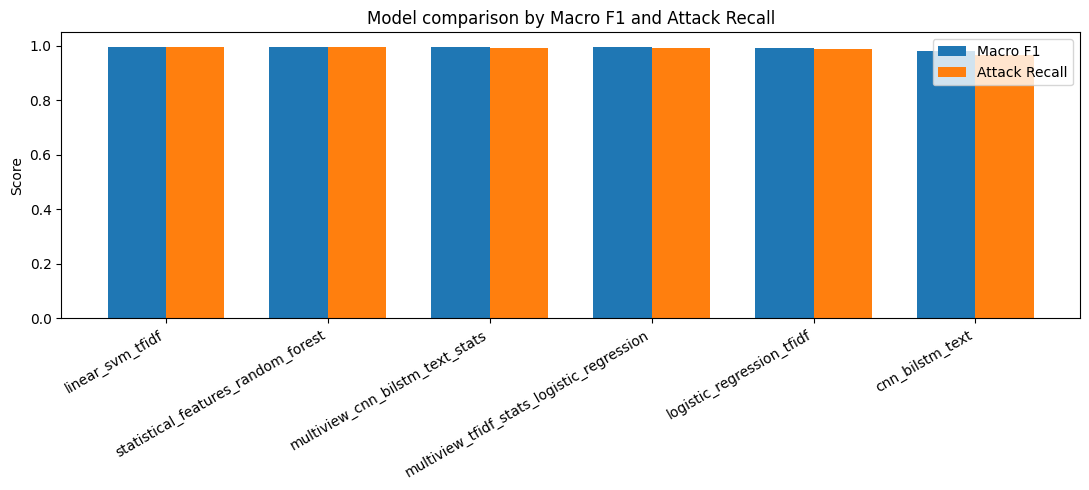

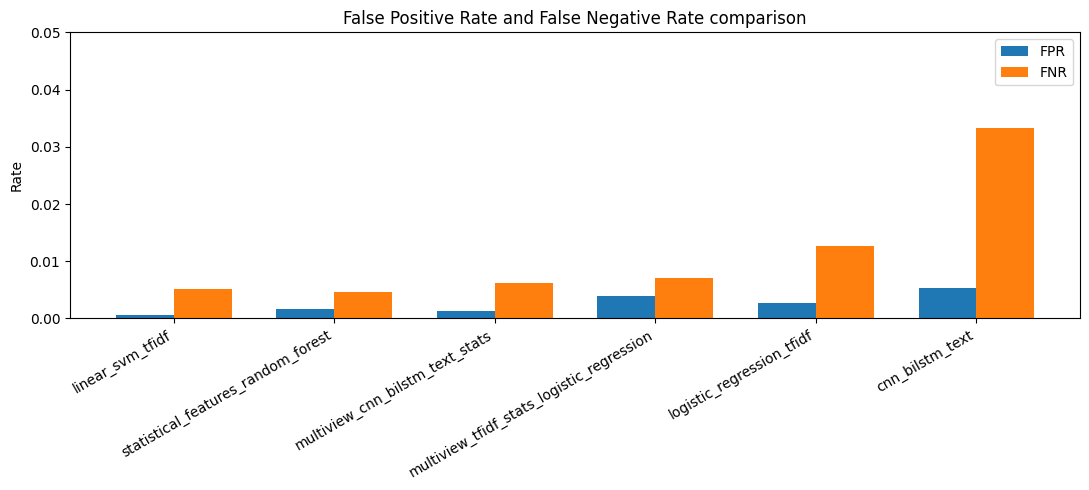

Best baseline: linear_svm_tfidf


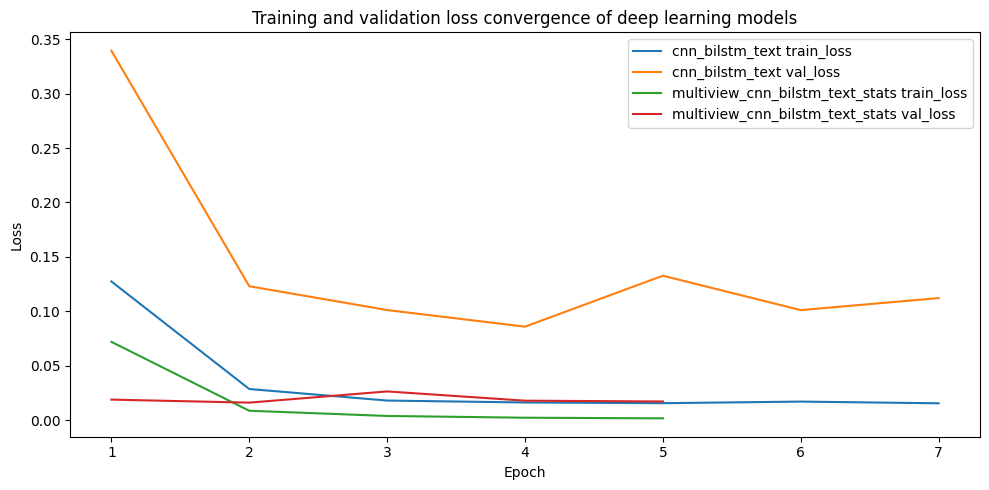

[2026-06-15T16:51:52] generate_summary_figures - OK: Final tables and required figures generated.


In [ ]:

# ============================================================
# CELL 20 - Generate final summary tables and required figures
# Required figures/tables for transparent report and slides.
# ============================================================
metric_files = sorted(RUN_SUBDIRS['metrics'].glob('*_metrics.json'))
rows = []
for fp in metric_files:
    try:
        obj = json.loads(fp.read_text(encoding='utf-8'))
        if obj.get('model_name'):
            rows.append(obj)
    except Exception as e:
        print('Skip metric file:', fp, e)

summary_df = pd.DataFrame(rows)
if summary_df.empty:
    raise RuntimeError('No model metrics found. Run model cells first.')

# Consistent sort: macro F1 first, then attack recall if available.
sort_cols = [c for c in ['f1_macro', 'attack_recall', 'accuracy'] if c in summary_df.columns]
summary_df = summary_df.sort_values(by=sort_cols, ascending=False)
safe_save_csv(summary_df, RUN_SUBDIRS['metrics'] / 'model_summary_table.csv')
safe_save_csv(summary_df, DIRS['reports'] / f'model_summary_table_{RUN_ID}.csv')
display(summary_df)

# Figure 2: Macro F1 and Attack Recall.
plot_df = summary_df.copy()
if 'attack_recall' not in plot_df.columns:
    plot_df['attack_recall'] = np.nan
fig_cols = ['f1_macro', 'attack_recall']
plt.figure(figsize=(11, 5))
x = np.arange(len(plot_df))
width = 0.36
plt.bar(x - width / 2, plot_df['f1_macro'], width, label='Macro F1')
plt.bar(x + width / 2, plot_df['attack_recall'], width, label='Attack Recall')
plt.xticks(x, plot_df['model_name'], rotation=30, ha='right')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.title('Model comparison by Macro F1 and Attack Recall')
plt.legend()
plt.tight_layout()
plt.savefig(RUN_SUBDIRS['figures'] / 'model_macro_f1_attack_recall.png', dpi=160)
plt.show()

# Figure 3: FPR/FNR.
if {'false_positive_rate', 'false_negative_rate'}.issubset(plot_df.columns):
    plt.figure(figsize=(11, 5))
    plt.bar(x - width / 2, plot_df['false_positive_rate'], width, label='FPR')
    plt.bar(x + width / 2, plot_df['false_negative_rate'], width, label='FNR')
    plt.xticks(x, plot_df['model_name'], rotation=30, ha='right')
    plt.ylabel('Rate')
    plt.ylim(0, max(0.05, float(np.nanmax(plot_df[['false_positive_rate', 'false_negative_rate']].values)) * 1.25))
    plt.title('False Positive Rate and False Negative Rate comparison')
    plt.legend()
    plt.tight_layout()
    plt.savefig(RUN_SUBDIRS['figures'] / 'model_fpr_fnr_comparison.png', dpi=160)
    plt.show()

# Figure 4 and 5: copy best baseline and proposed confusion matrix.
baseline_names = [
    'logistic_regression_tfidf',
    'linear_svm_tfidf',
    'statistical_features_random_forest',
    'multiview_tfidf_stats_logistic_regression',
]
proposed_name = 'multiview_cnn_bilstm_text_stats'

available_baselines = summary_df[summary_df['model_name'].isin(baseline_names)].copy()
if not available_baselines.empty:
    best_baseline = available_baselines.iloc[0]['model_name']
    src = RUN_SUBDIRS['figures'] / f'{best_baseline}_confusion_matrix.png'
    dst = RUN_SUBDIRS['figures'] / 'best_baseline_confusion_matrix.png'
    if src.exists():
        shutil.copy2(src, dst)
    print('Best baseline:', best_baseline)

proposed_src = RUN_SUBDIRS['figures'] / f'{proposed_name}_confusion_matrix.png'
proposed_dst = RUN_SUBDIRS['figures'] / 'proposed_model_confusion_matrix.png'
if proposed_src.exists():
    shutil.copy2(proposed_src, proposed_dst)

# Figure 6: loss convergence for deep models.
history_files = [
    RUN_SUBDIRS['metrics'] / 'cnn_bilstm_text_history.csv',
    RUN_SUBDIRS['metrics'] / 'multiview_cnn_bilstm_text_stats_history.csv',
]
plt.figure(figsize=(10, 5))
plotted = False
for hp in history_files:
    if hp.exists():
        hdf = pd.read_csv(hp)
        name = hp.name.replace('_history.csv', '')
        if 'loss' in hdf.columns:
            plt.plot(hdf['epoch'], hdf['loss'], label=f'{name} train_loss')
            plotted = True
        if 'val_loss' in hdf.columns:
            plt.plot(hdf['epoch'], hdf['val_loss'], label=f'{name} val_loss')
            plotted = True
if plotted:
    plt.title('Training and validation loss convergence of deep learning models')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(RUN_SUBDIRS['figures'] / 'deep_learning_loss_convergence.png', dpi=160)
    plt.show()
else:
    print('No deep learning history found for convergence plot.')

log_step('generate_summary_figures', 'OK', 'Final tables and required figures generated.')


In [ ]:

# ============================================================
# CELL 21 - Export best classical model and report artifacts for application
# Application demo uses a scikit-learn pipeline for stable deployment.
# ============================================================
summary_df = pd.read_csv(RUN_SUBDIRS['metrics'] / 'model_summary_table.csv')
exportable_names = [
    'logistic_regression_tfidf',
    'linear_svm_tfidf',
    'statistical_features_random_forest',
    'multiview_tfidf_stats_logistic_regression',
]
exportable_df = summary_df[summary_df['model_name'].isin(exportable_names)].copy()
if exportable_df.empty:
    raise RuntimeError('No exportable classical model found for application demo.')

sort_cols = [c for c in ['f1_macro', 'attack_recall', 'accuracy'] if c in exportable_df.columns]
exportable_df = exportable_df.sort_values(by=sort_cols, ascending=False)
best_export_name = exportable_df.iloc[0]['model_name']

best_info = model_registry.get(best_export_name)
if best_info is None:
    # Fallback: load from disk and infer input type.
    model_file = RUN_SUBDIRS['models'] / f'{best_export_name}.joblib'
    model_obj = joblib.load(model_file)
    if best_export_name == 'statistical_features_random_forest':
        input_type = 'numeric'
    elif best_export_name == 'multiview_tfidf_stats_logistic_regression':
        input_type = 'multiview'
    else:
        input_type = 'text'
else:
    model_obj = best_info['model']
    input_type = best_info['input_type']

bundle = {
    'model': model_obj,
    'model_name': best_export_name,
    'task_mode': TASK_MODE,
    'input_type': input_type,
    'text_col': text_col,
    'numeric_feature_cols': NUMERIC_FEATURE_COLS,
    'label_col': LABEL_COL,
    'run_id': RUN_ID,
    'created_at': now_iso(),
    'note': 'Exported for defensive Streamlit AI-WAF demo. The model does not execute requests.',
}

for target_dir in [RUN_SUBDIRS['artifacts'], DIRS['app_artifacts']]:
    target_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(bundle, target_dir / 'model_bundle.joblib')

    # Copy summary and audit files used by the app.
    shutil.copy2(RUN_SUBDIRS['metrics'] / 'model_summary_table.csv', target_dir / 'model_summary_table.csv')
    shutil.copy2(RUN_SUBDIRS['data'] / 'dataset_summary.csv', target_dir / 'dataset_summary.csv')
    shutil.copy2(RUN_SUBDIRS['data'] / 'label_distribution.csv', target_dir / 'label_distribution.csv')
    shutil.copy2(RUN_SUBDIRS['metrics'] / 'leakage_audit.json', target_dir / 'leakage_audit.json')

# Export dataset-derived demo cases from test set. This avoids hardcoding exploit strings in the app.
demo_cases = (
    test_df.groupby('label_multiclass', group_keys=False)
    .apply(lambda x: x.sample(min(3, len(x)), random_state=SEED))
    .reset_index(drop=True)
)
demo_cols = ['source_dataset', 'label_binary', 'label_multiclass', 'raw_text', 'normalized_text']
demo_cases = demo_cases[[c for c in demo_cols if c in demo_cases.columns]]
safe_save_csv(demo_cases, RUN_SUBDIRS['artifacts'] / 'demo_cases.csv')
safe_save_csv(demo_cases, DIRS['app_artifacts'] / 'demo_cases.csv')

print('Exported application model bundle:', DIRS['app_artifacts'] / 'model_bundle.joblib')
print('Selected model for app:', best_export_name)
display(demo_cases.head(10))
log_step('export_application_artifacts', 'OK', f'Exported best app model: {best_export_name}', {'input_type': input_type})


Exported application model bundle: /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb/Application/artifacts/model_bundle.joblib
Selected model for app: linear_svm_tfidf


/tmp/ipykernel_6330/974853149.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(3, len(x)), random_state=SEED))


,source_dataset,label_binary,label_multiclass,raw_text,normalized_text
0,HTTPPARAMS_DATASET,1,CommandInjection,"dir+c:"",7,cmdi,anom ||+dir|c:""","dir c:"",7,cmdi,anom || dir|c:"""
1,HTTPPARAMS_DATASET,1,CommandInjection,a;id;,a;id;
2,HTTPPARAMS_DATASET,1,CommandInjection,"+dir+c:"",8,cmdi,anom $&&dir+c:""","dir c:"",8,cmdi,anom $&&dir c:"""
3,HTTPPARAMS_DATASET,0,Normal,7559,7559
4,SQLI_DATASET,0,Normal,paseo arco del ladrillo 48 10?h,paseo arco del ladrillo 48 10?h
5,SQLI_DATASET,0,Normal,"SELECT news,parallel FROM away WHERE victory...","select news,parallel from away where victory =..."
6,HTTPPARAMS_DATASET,1,PathTraversal,//../..{file},//../..{file}
7,HTTPPARAMS_DATASET,1,PathTraversal,/aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa...,/aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa...
8,HTTPPARAMS_DATASET,1,PathTraversal,c:/inetpub/wwwroot/global.asa,c:/inetpub/wwwroot/global.asa
9,SQLI_DATASET,1,SQLi,"1%' ) ) union all select null,null--","1%' ) ) union all select null,null--"


[2026-06-15T16:51:57] export_application_artifacts - OK: Exported best app model: linear_svm_tfidf


In [ ]:

# ============================================================
# CELL 22 - Resume/check latest run results
# ============================================================
print('Current run folder:', RUN_DIR)

print('\nSaved models:')
for f in sorted(RUN_SUBDIRS['models'].glob('*')):
    print(' ', f.name)

print('\nSaved metrics:')
for f in sorted(RUN_SUBDIRS['metrics'].glob('*')):
    print(' ', f.name)

print('\nSaved figures:')
for f in sorted(RUN_SUBDIRS['figures'].glob('*')):
    print(' ', f.name)

print('\nApplication artifacts:')
for f in sorted(DIRS['app_artifacts'].glob('*')):
    print(' ', f.name)

print('\nStep log tail:')
if STEP_LOG_PATH.exists():
    lines = STEP_LOG_PATH.read_text(encoding='utf-8').splitlines()
    for line in lines[-10:]:
        print(line)
else:
    print('No step log yet.')


Current run folder: /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb/Output/Runs/20260615_160314

Saved models:
  cnn_bilstm_text.keras
  cnn_bilstm_text_label_encoder.json
  linear_svm_tfidf.joblib
  logistic_regression_tfidf.joblib
  multiview_cnn_bilstm_text_stats.keras
  multiview_cnn_bilstm_text_stats_metadata.json
  multiview_cnn_bilstm_text_stats_stats_scaler.joblib
  multiview_tfidf_stats_logistic_regression.joblib
  statistical_features_random_forest.joblib

Saved metrics:
  cleaning_audit.json
  cnn_bilstm_text_classification_report.json
  cnn_bilstm_text_confusion_matrix.csv
  cnn_bilstm_text_history.csv
  cnn_bilstm_text_metrics.json
  leakage_audit.json
  linear_svm_tfidf_classification_report.json
  linear_svm_tfidf_confusion_matrix.csv
  linear_svm_tfidf_metrics.json
  logistic_regression_tfidf_classification_report.json
  logistic_regression_tfidf_confusion_matrix.csv
  logistic_regression_tfidf_metrics.json
  model_summary_table.csv
  multiview_cnn_bilstm_text_s

In [ ]:
# ============================================================
# OPTIONAL CELL - Export all classical models for Application v2
# Place this cell after the model training cells and after model_registry exists.
# It lets the Streamlit app compare multiple models live.
# ============================================================
import json
import shutil
import joblib
from pathlib import Path

exportable_names = [
    'logistic_regression_tfidf',
    'linear_svm_tfidf',
    'statistical_features_random_forest',
    'multiview_tfidf_stats_logistic_regression',
]

all_model_bundle = {
    'task_mode': TASK_MODE,
    'text_col': text_col,
    'numeric_feature_cols': NUMERIC_FEATURE_COLS,
    'label_col': LABEL_COL,
    'run_id': RUN_ID,
    'created_at': now_iso(),
    'note': 'Multi-model export for defensive Streamlit AI-WAF demo v2.',
    'models': {},
}

for model_name in exportable_names:
    info = model_registry.get(model_name)
    if info is None:
        model_file = RUN_SUBDIRS['models'] / f'{model_name}.joblib'
        if not model_file.exists():
            print('Skip missing model:', model_name)
            continue
        model_obj = joblib.load(model_file)
        if model_name == 'statistical_features_random_forest':
            input_type = 'numeric'
        elif model_name == 'multiview_tfidf_stats_logistic_regression':
            input_type = 'multiview'
        else:
            input_type = 'text'
    else:
        model_obj = info['model']
        input_type = info['input_type']

    all_model_bundle['models'][model_name] = {
        'model': model_obj,
        'model_name': model_name,
        'task_mode': TASK_MODE,
        'input_type': input_type,
        'text_col': text_col,
        'numeric_feature_cols': NUMERIC_FEATURE_COLS,
        'label_col': LABEL_COL,
        'run_id': RUN_ID,
        'created_at': now_iso(),
        'note': 'Exported for defensive multi-model comparison in Streamlit app v2.',
    }

for target_dir in [RUN_SUBDIRS['artifacts'], DIRS['app_artifacts']]:
    target_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(all_model_bundle, target_dir / 'all_model_bundle.joblib')

    # Also export one file per model for easier debugging.
    per_model_dir = target_dir / 'model_bundles'
    per_model_dir.mkdir(parents=True, exist_ok=True)
    for model_name, bundle in all_model_bundle['models'].items():
        joblib.dump(bundle, per_model_dir / f'{model_name}_bundle.joblib')

    # Copy supporting evidence files used by application v2.
    copy_pairs = [
        (RUN_SUBDIRS['metrics'] / 'model_summary_table.csv', target_dir / 'model_summary_table.csv'),
        (RUN_SUBDIRS['data'] / 'dataset_summary.csv', target_dir / 'dataset_summary.csv'),
        (RUN_SUBDIRS['data'] / 'label_distribution.csv', target_dir / 'label_distribution.csv'),
        (RUN_SUBDIRS['metrics'] / 'leakage_audit.json', target_dir / 'leakage_audit.json'),
    ]
    for src, dst in copy_pairs:
        if src.exists():
            shutil.copy2(src, dst)

print('Exported multi-model bundle:', DIRS['app_artifacts'] / 'all_model_bundle.joblib')
print('Exported models:', sorted(all_model_bundle['models'].keys()))


Exported multi-model bundle: /content/drive/MyDrive/UngDungHocMay_PhatHienTanCongWeb/Application/artifacts/all_model_bundle.joblib
Exported models: ['linear_svm_tfidf', 'logistic_regression_tfidf', 'multiview_tfidf_stats_logistic_regression', 'statistical_features_random_forest']
